In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Literal

In [8]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int
    equation : str
    discriminant : float
    result: str


In [10]:
def show_equation(state: QuadState) :
    equation = f"{state['a']}x^2 + {state['b']}x + {state['c']} = 0"
    return {'equation':equation}


def calculate_discrimininent(state: QuadState) :
    a = state['a']
    b = state['b']
    c = state['c']
    discriminant = b**2 - 4*a*c
    return {'discriminant': discriminant}

def real_roots(state: QuadState) :
    root1 = (-state['b'] + state['discriminant']**0.5) / (2*state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5) / (2*state['a'])
    return {'result': f"Real roots are : {root1} and {root2}" }

def repeating_roots(state: QuadState) :
    root = -state['b'] / (2*state['a'])
    return {'result': f"Repeating root is : {root}" }   

def no_real_roots(state: QuadState) :
    return {'result': "No real roots exist." }

In [11]:
def conditional_branch(state: QuadState) -> Literal['real_roots', 'repeating_roots', 'no_real_roots']:
    if state['discriminant'] > 0:
        return 'real_roots'
    elif state['discriminant'] == 0:
        return 'repeating_roots'
    else:
        return 'no_real_roots'

In [12]:
graph = StateGraph(QuadState)


graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discrimininent',calculate_discrimininent)
graph.add_node('real_roots',real_roots)
graph.add_node('repeating_roots',repeating_roots)
graph.add_node('no_real_roots',no_real_roots)


graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discrimininent')
graph.add_conditional_edges('calculate_discrimininent',conditional_branch)
graph.add_edge('real_roots',END)
graph.add_edge('repeating_roots',END)   
graph.add_edge('no_real_roots',END)


workflow =graph.compile()



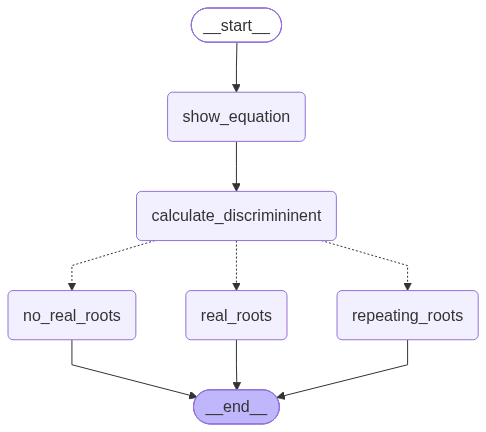

In [13]:
workflow

In [14]:
initial_state = {
    'a': 1,
    'b': -3,
    'c': 2}

workflow.invoke(initial_state)


{'a': 1,
 'b': -3,
 'c': 2,
 'equation': '1x^2 + -3x + 2 = 0',
 'discriminant': 1,
 'result': 'Real roots are : 2.0 and 1.0'}